# `tsl.ipynb`: topological speed limits of GRN evolution

In [1]:
import jax
from jax import numpy as jnp
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
from pathlib import Path
from tqdm import tqdm

from utils.modelIO import *
from utils.tsl import *

initialize

In [17]:
GIDS_PATH = Path('data/eml/eml_gene_ids.csv')
BIO_GRN_PATH = Path('data/eml/eml_fate_network.npy')
FIG_SAVE_PATH = Path('figs/eml/')

_, _, N = load_grn(BIO_GRN_PATH, GIDS_PATH)
get_histogram_vmap = jax.vmap(get_histogram, in_axes=(0, None))
geom = geometry.Geometry(cost_matrix=get_bit_cost_matrix(2**N))

load data and compute Wasserstein distances

In [3]:
bio_xs = jnp.load('results/eml/tsl/bio_many_xs.npy').T
bio_hists = get_histogram_vmap(bio_xs, N)
del bio_xs

bio_w1s = jnp.array([])
for hist in tqdm(bio_hists[1:]):
    w1 = get_wasserstein1(geom, bio_hists[0], hist)
    bio_w1s = jnp.append(bio_w1s, w1)

bio_w1s

100%|██████████| 14/14 [1:48:04<00:00, 463.16s/it]


Array([2.1057425, 3.0064507, 3.4655268, 3.7061472, 3.8555877, 3.957199 ,
       4.0292   , 4.080883 , 4.1262517, 4.162671 , 4.1940074, 4.212813 ,
       4.2328067, 4.245484 ], dtype=float32)

In [4]:
del bio_hists
rand_xs = jnp.load('results/eml/tsl/rand_many_xs.npy').T
rand_hists = get_histogram_vmap(rand_xs, N)
del rand_xs

rand_w1s = jnp.array([])
for hist in tqdm(rand_hists[1:]):
    w1 = get_wasserstein1(geom, rand_hists[0], hist)
    rand_w1s = jnp.append(rand_w1s, w1)

rand_w1s

100%|██████████| 14/14 [30:16<00:00, 129.75s/it]


Array([0.54895985, 0.6561316 , 0.7058448 , 0.73039216, 0.7482005 ,
       0.75784004, 0.76464677, 0.7722028 , 0.7747209 , 0.7774159 ,
       0.7770381 , 0.7806619 , 0.7803266 , 0.78250813], dtype=float32)

compute speed limits

In [24]:
bio_vs = jnp.load('results/eml/tsl/bio_many_vs.npy')
rand_vs = jnp.load('results/eml/tsl/rand_many_vs.npy')

bio_avg_v = bio_vs.sum(axis=0).cumsum()/jnp.arange(1, bio_vs.shape[1]+1)
rand_avg_v = rand_vs.sum(axis=0).cumsum()/jnp.arange(1, rand_vs.shape[1]+1)

bio_tmins = jnp.concatenate((jnp.zeros(1), bio_w1s/bio_avg_v))*bio_vs.shape[0]
rand_tmins = jnp.concatenate((jnp.zeros(1), rand_w1s/rand_avg_v))*rand_vs.shape[0]

plot speed limits

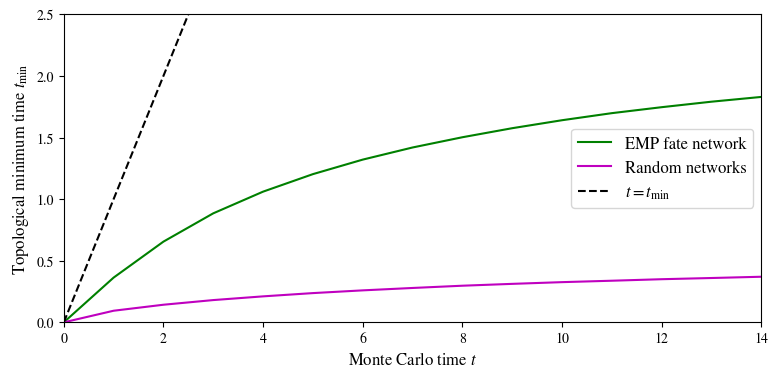

In [26]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(jnp.arange(bio_w1s.shape[0]+1), bio_tmins, color='g', label='EMP fate network')
ax.plot(jnp.arange(rand_w1s.shape[0]+1), rand_tmins, color='m', label='Random networks')
ax.plot(jnp.arange(bio_w1s.shape[0]+1), jnp.arange(bio_w1s.shape[0]+1), 'k--', label=r'$t=t_\text{min}$')
ax.set_xlim(0, 14)
ax.set_ylim(0, 2.5)
ax.ticklabel_format(axis='y', style='scientific')
ax.legend(fontsize=12)
ax.set_xlabel(r'Monte Carlo time $t$', fontsize=12)
ax.set_ylabel(r'Topological minimum time $t_\text{min}$', fontsize=12)
plt.savefig(FIG_SAVE_PATH.joinpath('tsl.pdf'), bbox_inches='tight')